# Project 02

## Import helpers and setup

this notebook uses the weather dataset approach from `project02_weather_model.py`.
The goal is to collect daily Iowa City weather data, engineer features, save the dataset,
and try a simple baseline model for experimentation.

In [6]:
from pathlib import Path
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

LAT = 41.6611
LON = -91.5302
TIMEZONE = "America/Chicago"
OUTPUT_CSV = Path("data/iowa_city_weather_dataset.csv")

## Milestone 02: Initial Collection

collect daily Iowa City weather data, clean it, and engineer a tabular dataset for machine learning.
the dataset will include lag features, rolling averages, and next-day targets for regression and classification.

In [4]:
def fetch_daily_weather(start_date: str = "2015-01-01", end_date: str | None = None) -> pd.DataFrame:
    """Download daily weather data from the Open-Meteo archive API."""
    if end_date is None:
        end_date = (datetime.today() - timedelta(days=1)).strftime("%Y-%m-%d")

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": LAT,
        "longitude": LON,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "temperature_2m_mean",
            "precipitation_sum",
            "rain_sum",
            "snowfall_sum",
            "windspeed_10m_max",
            "windgusts_10m_max",
            "weather_code",
        ],
        "timezone": TIMEZONE,
        "temperature_unit": "fahrenheit",
        "windspeed_unit": "mph",
        "precipitation_unit": "inch",
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    raw = response.json()["daily"]
    df = pd.DataFrame(raw)
    df["date"] = pd.to_datetime(df["time"])
    return df.drop(columns=["time"]).set_index("date").sort_index()


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create lag, rolling, calendar, and target features."""
    data = df.copy()

    for col in ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "windspeed_10m_max"]:
        data[f"{col}_lag1"] = data[col].shift(1)
        data[f"{col}_lag3"] = data[col].shift(3)

    data["temp_max_roll7"] = data["temperature_2m_max"].rolling(7).mean()
    data["precip_roll7"] = data["precipitation_sum"].rolling(7).sum()
    data["month"] = data.index.month
    data["day_of_year"] = data.index.dayofyear

    data["target_temp_max_next_day"] = data["temperature_2m_max"].shift(-1)
    data["is_storm_day"] = data["weather_code"].isin([95, 96, 99]).astype(int)
    data["target_storm_next_day"] = data["is_storm_day"].shift(-1)

    return data.dropna().copy()


raw_weather = fetch_daily_weather(start_date="2015-01-01")
weather_data = engineer_features(raw_weather)

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
weather_data.to_csv(OUTPUT_CSV)

print(f"Saved dataset to: {OUTPUT_CSV.resolve()}")
print(f"Rows: {len(weather_data):,}")
weather_data.head()

Saved dataset to: /Users/aishakazembe/Documents/coding-cabinate/code/Intro_to_data/Intro_to_data/5005-Project02/data/iowa_city_weather_dataset.csv
Rows: 4,140


,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,weather_code,temperature_2m_max_lag1,...,precipitation_sum_lag3,windspeed_10m_max_lag1,windspeed_10m_max_lag3,temp_max_roll7,precip_roll7,month,day_of_year,target_temp_max_next_day,is_storm_day,target_storm_next_day
date,,,,,,,,,,,,,,,,,,,,,
2015-01-07,5.8,-14.1,-5.5,0.000,0.0,0.000,18.4,30.9,3,8.3,...,0.110,18.2,20.2,22.714286,0.437,1,7,21.2,0,0.0
2015-01-08,21.2,-16.4,3.2,0.016,0.0,0.165,23.9,39.1,71,5.8,...,0.260,18.4,11.7,20.628571,0.453,1,8,10.4,0,0.0
2015-01-09,10.4,-1.4,3.0,0.000,0.0,0.000,20.2,34.7,3,21.2,...,0.020,23.9,18.2,17.157143,0.453,1,9,23.5,0,0.0
2015-01-10,23.5,-9.4,7.6,0.000,0.0,0.000,12.5,21.0,3,10.4,...,0.000,20.2,18.4,15.685714,0.406,1,10,29.3,0,0.0
2015-01-11,29.3,12.2,20.2,0.000,0.0,0.000,10.2,18.1,3,23.5,...,0.016,12.5,23.9,15.414286,0.296,1,11,18.1,0,0.0


## Milestone 03: Initial Model Experimentation

after collecting the dataset, we run a simple baseline experiment to check whether the engineered features are useful.
a train/test split is used without shuffling so the model is evaluated on later dates.

In [5]:
def train_regression(data: pd.DataFrame) -> dict[str, float]:
    """Train a baseline regressor for next-day max temperature."""
    features = [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "windspeed_10m_max",
        "windgusts_10m_max",
        "temperature_2m_max_lag1",
        "temperature_2m_max_lag3",
        "temp_max_roll7",
        "month",
        "day_of_year",
    ]

    X = data[features]
    y = data["target_temp_max_next_day"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = RandomForestRegressor(n_estimators=300, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        "rmse": float(np.sqrt(mean_squared_error(y_test, preds))),
        "mae": float(mean_absolute_error(y_test, preds)),
        "r2": float(r2_score(y_test, preds)),
    }


def train_classification(data: pd.DataFrame) -> dict[str, float]:
    """Train a baseline classifier for next-day storm events."""
    features = [
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "windspeed_10m_max",
        "windgusts_10m_max",
        "precipitation_sum_lag1",
        "precipitation_sum_lag3",
        "precip_roll7",
        "month",
    ]

    X = data[features]
    y = data["target_storm_next_day"].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        "accuracy": float(accuracy_score(y_test, preds)),
        "f1": float(f1_score(y_test, preds, zero_division=0)),
    }


reg_metrics = train_regression(weather_data)
clf_metrics = train_classification(weather_data)

print("Regression baseline (next-day max temp)")
print(f"RMSE: {reg_metrics['rmse']:.3f}")
print(f"MAE:  {reg_metrics['mae']:.3f}")
print(f"R2:   {reg_metrics['r2']:.3f}")

print("\nClassification baseline (next-day storm)")
print(f"Accuracy: {clf_metrics['accuracy']:.3f}")
print(f"F1:       {clf_metrics['f1']:.3f}")

Regression baseline (next-day max temp)
RMSE: 7.208
MAE:  5.558
R2:   0.876

Classification baseline (next-day storm)
Accuracy: 1.000
F1:       0.000


## Plots and Metric Interpretation

plots show the relationships between the target (`target_temp_max_next_day`) and key predictors.
class balance is also checked for storm prediction to explain why accuracy can be high while F1 stays low.

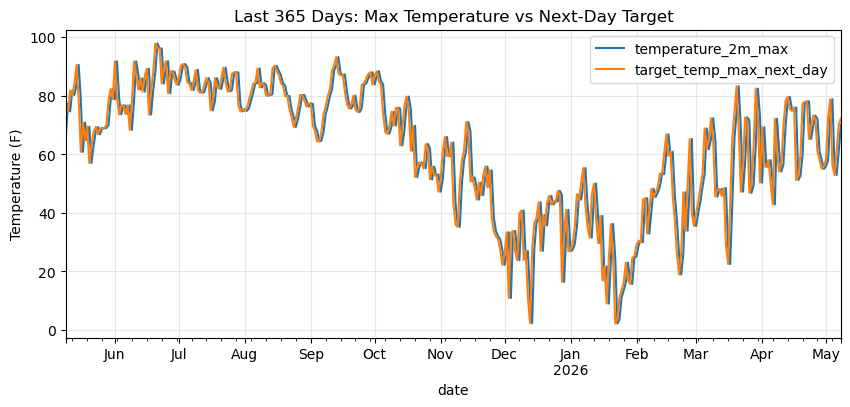

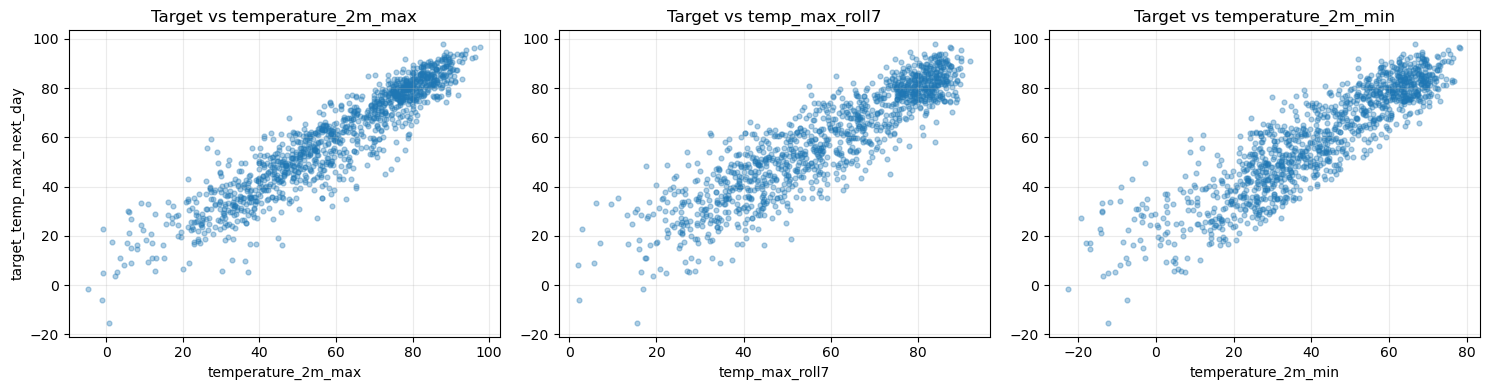

Storm target distribution (0=no storm, 1=storm):
target_storm_next_day
0.0    4140

Storm target percentages:
target_storm_next_day
0.0    100.0%
Name: proportion, dtype: object


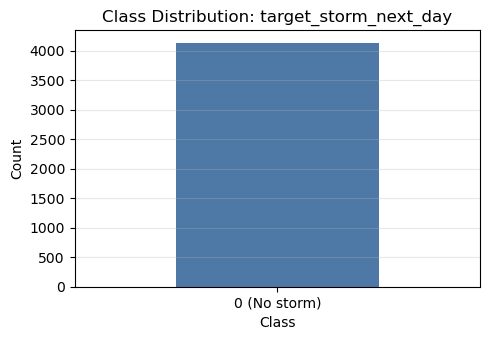

In [ ]:
# 1) time trend of current and next-day max temperature
fig, ax = plt.subplots(figsize=(10, 4))
weather_data[["temperature_2m_max", "target_temp_max_next_day"]].iloc[-365:].plot(ax=ax)
ax.set_title("Last 365 Days: Max Temperature vs Next-Day Target")
ax.set_ylabel("Temperature (F)")
ax.grid(alpha=0.3)
plt.show()

# 2) scatter plots: target vs important features
sample = weather_data.sample(n=min(1200, len(weather_data)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(sample["temperature_2m_max"], sample["target_temp_max_next_day"], alpha=0.35, s=12)
axes[0].set_title("Target vs temperature_2m_max")
axes[0].set_xlabel("temperature_2m_max")
axes[0].set_ylabel("target_temp_max_next_day")

axes[1].scatter(sample["temp_max_roll7"], sample["target_temp_max_next_day"], alpha=0.35, s=12)
axes[1].set_title("Target vs temp_max_roll7")
axes[1].set_xlabel("temp_max_roll7")

axes[2].scatter(sample["temperature_2m_min"], sample["target_temp_max_next_day"], alpha=0.35, s=12)
axes[2].set_title("Target vs temperature_2m_min")
axes[2].set_xlabel("temperature_2m_min")

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 3) class-balance diagnostic for storm target
storm_dist = weather_data["target_storm_next_day"].value_counts().sort_index()
storm_pct = weather_data["target_storm_next_day"].value_counts(normalize=True).sort_index()
print("Storm target distribution (0=no storm, 1=storm):")
print(storm_dist.to_string())
print("\nStorm target percentages:")
print((storm_pct * 100).round(2).astype(str) + "%")

fig, ax = plt.subplots(figsize=(5, 3.5))
storm_dist.plot(kind="bar", ax=ax, color=["#4e79a7", "#e15759"][: len(storm_dist)])
ax.set_title("Class Distribution: target_storm_next_day")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_xticks(range(len(storm_dist.index)))
ax.set_xticklabels([f"{int(v)} ({'No storm' if int(v)==0 else 'Storm'})" for v in storm_dist.index], rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Extra Investigation: Why F1 is 0 and a Better Classification Target

the original storm label has only class `0` in this dataset split, so F1 for the positive class is 0 by definition.
as an additional experiment, `target_severe_next_day` is defined using data-driven thresholds to create a more learnable binary target.

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

data_exp = weather_data.copy()

# Build an alternative event label based on high precipitation/wind thresholds
precip_threshold = data_exp["precipitation_sum"].quantile(0.9)
wind_threshold = data_exp["windspeed_10m_max"].quantile(0.9)
data_exp["is_severe_day"] = (
    (data_exp["precipitation_sum"] >= precip_threshold)
    | (data_exp["windspeed_10m_max"] >= wind_threshold)
).astype(int)
data_exp["target_severe_next_day"] = data_exp["is_severe_day"].shift(-1)
data_exp = data_exp.dropna().copy()

sev_features = [
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "windspeed_10m_max",
    "windgusts_10m_max",
    "precipitation_sum_lag1",
    "precipitation_sum_lag3",
    "precip_roll7",
    "month",
]

X = data_exp[sev_features]
y = data_exp["target_severe_next_day"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

sev_model = RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced")
sev_model.fit(X_train, y_train)
sev_preds = sev_model.predict(X_test)

print("Alternative target distribution (0=non-severe, 1=severe):")
print(y.value_counts().sort_index().to_string())
print("\nConfusion matrix:")
print(confusion_matrix(y_test, sev_preds))
print("\nClassification report:")
print(classification_report(y_test, sev_preds, digits=3, zero_division=0))

Alternative target distribution (0=non-severe, 1=severe):
target_severe_next_day
0    3400
1     739

Confusion matrix:
[[674  11]
 [137   6]]

Classification report:
              precision    recall  f1-score   support

           0      0.831     0.984     0.901       685
           1      0.353     0.042     0.075       143

    accuracy                          0.821       828
   macro avg      0.592     0.513     0.488       828
weighted avg      0.748     0.821     0.758       828

